
# 概率编程与贝叶斯方法(黑客版)—— 中文·现代 PyMC 版

##### 版本 0.1 (中文·现代 PyMC 移植版)

`原著: Cam Davidson-Pilon`

`Python 3 / PyMC3 移植: Max Margenot (@clean_utensils), Thomas Wiecki (@twiecki), Quantopian`

`PyMC (最新第 4 代) 移植: Kurisu Chan (@miemiekurisu)`

`中文翻译、现代 PyMC (6.x) 适配与内容增补: 本 fork 维护者`

___

欢迎阅读《概率编程与贝叶斯方法(黑客版)》。英文原版仓库见
[github/Probabilistic-Programming-and-Bayesian-Methods-for-Hackers](https://github.com/CamDavidsonPilon/Probabilistic-Programming-and-Bayesian-Methods-for-Hackers),
本仓库是它的一个 fork,在原版基础上做了三件事:

1. **修复并验证代码可以在当前版本的 PyMC 上端到端运行**(原版部分章节使用的是已被废弃的 API,比如 `Model.initial_values`)。
2. **把全部正文翻译成中文**,并在原文过于精简的地方补充解释,而不是逐字硬译。
3. **补充一些现代 PyMC 工作流中的标准实践**,比如用 `arviz` 的 `InferenceData` 结构来管理和诊断后验样本,这是原版成书时(PyMC2/3 时代)还不存在的推荐做法。

每一章都同时提供 Jupyter Notebook (`.ipynb`) 和 Org-mode (`.org`) 两种格式,内容保持同步。希望这个版本能帮助更多中文读者跨过"看得懂公式,但不知道怎么写代码"这道坎。



# 第一章
***



## 贝叶斯推断的哲学

> 你是一位技艺娴熟的程序员,但代码里还是会不可避免地混入 bug。在完成一段特别复杂的算法实现之后,你决定先用一个简单的例子测试一下代码。测试通过了。你又用一个更难的问题测试,依然通过。接下来是一个*更难*的测试,居然还是通过了!你开始相信,这段代码里可能根本没有 bug……

如果你也是这么想的,恭喜你,你已经在用贝叶斯的方式思考问题了!贝叶斯推断,说白了,就是"在看到新证据之后更新自己的信念"。一个贝叶斯主义者几乎永远无法对一个结论100%确定,但可以变得*非常有信心*。就像上面的例子一样,除非你测试了所有可能出现的情况(这在实践中几乎不可能),否则永远不能100%确定代码没有 bug。但我们可以在大量的情形下测试它,如果都通过了,我们就可以对代码更*有信心*,尽管依然不是绝对确定。贝叶斯推断的运作方式完全一样:我们不断更新对某个结果的信念,除非排除了所有其他可能性,否则很少能做到彻底确定。



### 贝叶斯式的思维方式

贝叶斯推断与更传统的统计推断的不同之处在于,它保留了*不确定性*。乍一听这好像是个糟糕的统计手段——统计学不就是要从随机性中提炼出*确定性*吗?为了理清这一点,我们需要先像贝叶斯主义者一样思考。

贝叶斯世界观把概率解释为*对某个事件的可信程度*的度量,也就是说,我们对某件事会发生这件事有多大把握。事实上,我们很快就会看到,这其实是概率最自然的解读方式。

为了讲清楚这一点,我们先看看概率的另一种解读:*频率学派*,也就是更"经典"的那一派统计学,认为概率是事件发生的长期频率(这也是它名字的由来)。举个例子,在频率学派的哲学下,"飞机失事的概率"被解读为"飞机失事的长期发生频率"。这对很多事件是说得通的,但当一件事根本没有"长期频率"可言时,这套解释就变得难以理解了。想想看:我们常常会给总统大选的结果赋予概率,但选举本身只会发生*一次*!频率学派为了绕开这个问题,不得不诉诸"平行世界"的说法:在所有这些平行世界中,某个结果出现的频率就定义了它的概率。

而贝叶斯主义者则采取了一种更直觉化的方式。贝叶斯主义者把概率解释为对某个事件发生的*信念*或信心程度的度量。简单来说,概率就是一种意见的总结。一个人如果对某件事赋予 0 的信念,就表示他完全不相信这件事会发生;反过来,赋予 1 则表示他完全确信这件事一定会发生。0 到 1 之间的信念值则允许对其他可能结果加权考虑。这个定义与"飞机失事概率"的例子是吻合的——在观察到飞机失事的频率之后,一个人的信念理应等于这个频率(在没有其他额外信息的情况下)。同样,在"概率等于信念"这个定义下,谈论总统大选结果的概率(信念)也就变得有意义了:你有多大把握认为候选人 *A* 会赢?

请注意,在上一段中,我把信念(概率)这个度量赋给了*某个个体*,而不是"自然界"本身。这一点非常有意思,因为这个定义为"不同个体持有不同信念"留出了空间。这恰恰符合现实中发生的情况:不同的人对同一件事会有不同的信念,因为他们掌握着不同的*信息*。不同信念的存在,并不意味着其中一定有人是错的。下面几个例子说明了个体信念与概率之间的关系:

- 我抛一枚硬币,我们俩都来猜结果。假设硬币是均匀的,我们都会同意正面朝上的概率是 1/2。现在假设我偷看了一眼硬币,我现在已经确切地知道了结果:我会把 1.0 的概率赋给正面(或反面,视情况而定)。那么*你*现在认为硬币是正面朝上的信念是多少?我的知识变化并没有改变硬币本身的结果,但我们俩赋予的概率却不一样了。

- 你的代码里要么有 bug,要么没有,但我们并不能确定究竟是哪种情况,只是对"是否存在 bug"这件事持有某种信念。

- 一位病人表现出症状 $x$、$y$ 和 $z$。有好几种疾病都可能导致这些症状,但实际上只有一种疾病真正存在。一位医生对"是哪种疾病"持有自己的信念,而另一位医生的信念可能略有不同。

把信念当作概率来对待,这种思维方式对人类而言是十分自然的。我们在与世界互动、只能看到部分真相、需要不断收集证据来形成信念的过程中,一直在下意识地使用这种思维方式。相反,要像频率学派那样思考,反倒是需要经过*专门训练*才能做到的。

为了和传统概率记号保持一致,我们把对事件 $A$ 的信念记作 $P(A)$,并称之为*先验概率*(prior probability)。

伟大的经济学家与思想家约翰·梅纳德·凯恩斯曾说过:"当事实改变时,我就会改变我的看法。先生,您又是怎么做的呢?"这句话恰恰反映了贝叶斯主义者在看到证据后更新信念的方式——即使(尤其是)证据与最初的信念相悖,这个证据也不能被忽视。我们把更新后的信念记作 $P(A \mid X)$,读作"在证据 $X$ 之下, $A$ 成立的概率"。我们把这个更新后的信念称为*后验概率*(posterior probability),以便和先验概率区分开来。举例来说,在观察到某些证据 $X$ 之后,上面几个例子对应的后验概率(即后验信念)分别是:

1. $P(A)$:硬币有 50% 的概率是正面。$P(A \mid X)$:你看了一眼硬币,观察到正面朝上,把这条信息记作 $X$,于是理所当然地把 1.0 的概率赋给正面、0.0 赋给反面。

2. $P(A)$:这段又大又复杂的代码很可能有 bug。$P(A \mid X)$:代码通过了全部 $X$ 项测试;虽然仍可能有 bug,但存在的可能性已经降低了。

3. $P(A)$:病人可能患有多种疾病中的任意一种。$P(A \mid X)$:一项血液检测产生了证据 $X$,排除了其中一部分可能的疾病。

可以看到,在每一个例子里,我们在看到新证据 $X$ 之后,并没有完全抛弃先验信念,而是*重新为先验加权*,把新证据纳入考量之中(也就是说,我们对某些信念给予了更多的权重/信心,而对另一些给予了更少)。

通过为事件引入先验的不确定性,我们其实已经承认:自己所做的任何猜测都有可能是错的。在观察到数据、证据或其他信息之后,我们更新自己的信念,让猜测变得*不那么错*。这正是"预测"这枚硬币的另一面——通常我们总想着要变得*更对*,而贝叶斯的视角提醒我们,更实际的目标或许是"更不错"。



### 贝叶斯推断的实践

如果说频率学派推断和贝叶斯推断都是编程里的函数,输入是统计问题,那么这两个函数返回给用户的东西是不同的。频率学派推断函数会返回一个数字,代表某种估计值(通常是样本均值之类的汇总统计量);而贝叶斯函数返回的则是*概率*。

举个例子,在上面调试代码的问题里,如果调用频率学派函数,传入的参数是"我的代码通过了全部 $X$ 项测试,代码没有 bug 吗?",它会返回一个 *是*。而如果我们问贝叶斯函数"我的代码经常有 bug。我的代码通过了全部 $X$ 项测试,代码没有 bug 吗?",得到的答案会截然不同:*是* 和 *否* 各自的概率。这个函数可能会返回:

> *是*,概率为 0.8;*否*,概率为 0.2

这和频率学派函数给出的答案非常不同。注意到贝叶斯函数多接受了一个参数:*"我的代码经常有 bug"*。这个参数就是*先验*。通过引入这个先验参数,我们相当于告诉贝叶斯函数,要把我们对这个情境的既有信念也纳入考虑。从技术上讲,贝叶斯函数里的这个参数是可选的,但我们会看到,省略它自有其代价。

#### 融入新证据

随着我们积累越来越多的证据,先验信念会逐渐被新证据"冲淡"。这是符合预期的。举个例子,如果你的先验信念荒谬得离谱,比如"我预计太阳今天会爆炸",而每天都被证明是错的,你自然会希望某种推断机制能够纠正你,或者至少让你的信念变得更靠谱一些。贝叶斯推断正是会这样纠正这类信念。

记 $N$ 为我们所掌握的证据数量。当我们积累*无穷多*的证据,也就是 $N \rightarrow \infty$ 时,贝叶斯的结果(通常)会和频率学派的结果趋于一致。所以当 $N$ 很大时,统计推断在某种程度上会变得较为客观。反过来,当 $N$ 很小时,推断会变得更加*不稳定*:频率学派的估计会有更大的方差、更宽的置信区间。而这正是贝叶斯分析大显身手的地方。通过引入先验、并返回概率(而不是单一的标量估计值),我们*保留了不确定性*,如实反映出小样本 $N$ 下统计推断本身固有的不稳定性。

有人可能会想,既然 $N$ 很大时两种方法给出的推断结果相近,那么不如索性偏向计算上更简单的频率学派方法。在做出这个决定之前,不妨先想想安德鲁·盖尔曼(Andrew Gelman, 2005)[1] 的这段话:

> 样本量永远不会真正"大"。如果 $N$ 太小,不足以得到足够精确的估计,你就需要更多数据(或者做出更多假设)。但一旦 $N$ "足够大"了,你就可以开始细分数据来学到更多东西了(比如在一项民意调查中,一旦你对全国有了一个不错的估计,你就可以进一步分性别、分南北方、分不同年龄段来估计)。$N$ 从来都不够,因为一旦它真的"够了",你早就已经转向下一个需要更多数据的问题了。

### 那么频率学派方法就是错的吗?

**不是的。**

频率学派方法在很多领域依然十分有用,甚至代表着最先进的水平。最小二乘线性回归、LASSO 回归、期望最大化(EM)算法等工具都强大而高效。贝叶斯方法是对这些技术的补充——它能解决这些方法无法解决的问题,或者用更灵活的建模方式来揭示系统背后的机理。

#### 关于*大数据*的一点说明

颇具讽刺意味的是,大数据的预测分析问题,实际上往往是靠相对简单的算法解决的 [2][4]。因此可以说,大数据带来的预测难题,其困难并不在于算法本身,而在于对海量数据进行存储和执行运算时面临的计算难题(这里也不妨再想想盖尔曼那句话,问问自己:"我真的拥有'大数据'吗?")。

真正更棘手的分析问题,恰恰出现在*中等规模数据*,尤其麻烦的是*非常小的数据集*上。沿用盖尔曼上面的论证方式:如果大数据问题已经"大"到很容易被解决,那么我们真正应该关注的,反而是那些"还不够大"的数据集。



### 我们的贝叶斯框架

我们关心的是信念,而用贝叶斯的方式思考,信念可以被解读为概率。我们对事件 $A$ 持有一个*先验*信念,这个信念由此前已有的信息构成——比如,在做任何测试之前,我们对代码中是否存在 bug 的先验信念。

接下来,我们观察证据。继续用"代码有 bug"的例子:如果我们的代码通过了 $X$ 项测试,我们希望把这一点纳入更新后的信念之中。我们把这个新的信念称为*后验*概率。更新信念的过程由下面这个方程完成,它就是以发现者托马斯·贝叶斯命名的贝叶斯定理:

\begin{align}
 P( A | X ) = & \frac{ P(X | A) P(A) } {P(X) } \\\\[5pt]
& \propto P(X | A) P(A)\;\; (\propto \text{表示"正比于"})
\end{align}

上面这个公式并非贝叶斯推断所独有——它是一个数学事实,在贝叶斯推断之外也有其他用途。贝叶斯推断只是借助它,把先验概率 $P(A)$ 和更新后的后验概率 $P(A \mid X)$ 联系了起来。



##### 示例:必不可少的抛硬币例子

每一本统计学教材都少不了一个抛硬币的例子,这里我们也用它来"交个差"。假设你天真地不确定抛硬币正面朝上的概率是多少(剧透一下:是 50%)。你相信存在某个真实的底层比例,记为 $p$,但对 $p$ 到底可能是多少没有任何先验意见。

我们开始抛硬币,并记录观测结果:$H$(正面)或 $T$(反面)。这就是我们观测到的数据。一个有意思的问题是:随着我们观察到越来越多的数据,我们的推断会如何变化?更具体地说,当我们只有很少数据、和拥有大量数据时,后验概率分别长什么样?

下面我们画出一系列后验概率随着观测数据(抛硬币次数)增多而不断更新的过程。


Font 'default' does not have a glyph for '\u6b63' [U+6b63], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u9762' [U+9762], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u671d' [U+671d], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u4e0a' [U+4e0a], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7684' [U+7684], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u7684' [U+7684], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6982' [U+6982], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7387' [U+7387], substituting with a dummy symbol.


/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 35266 (\N{CJK UNIFIED IDEOGRAPH-89C2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 25243 (\N{CJK UNIFIED IDEOGRAPH-629B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 

/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 

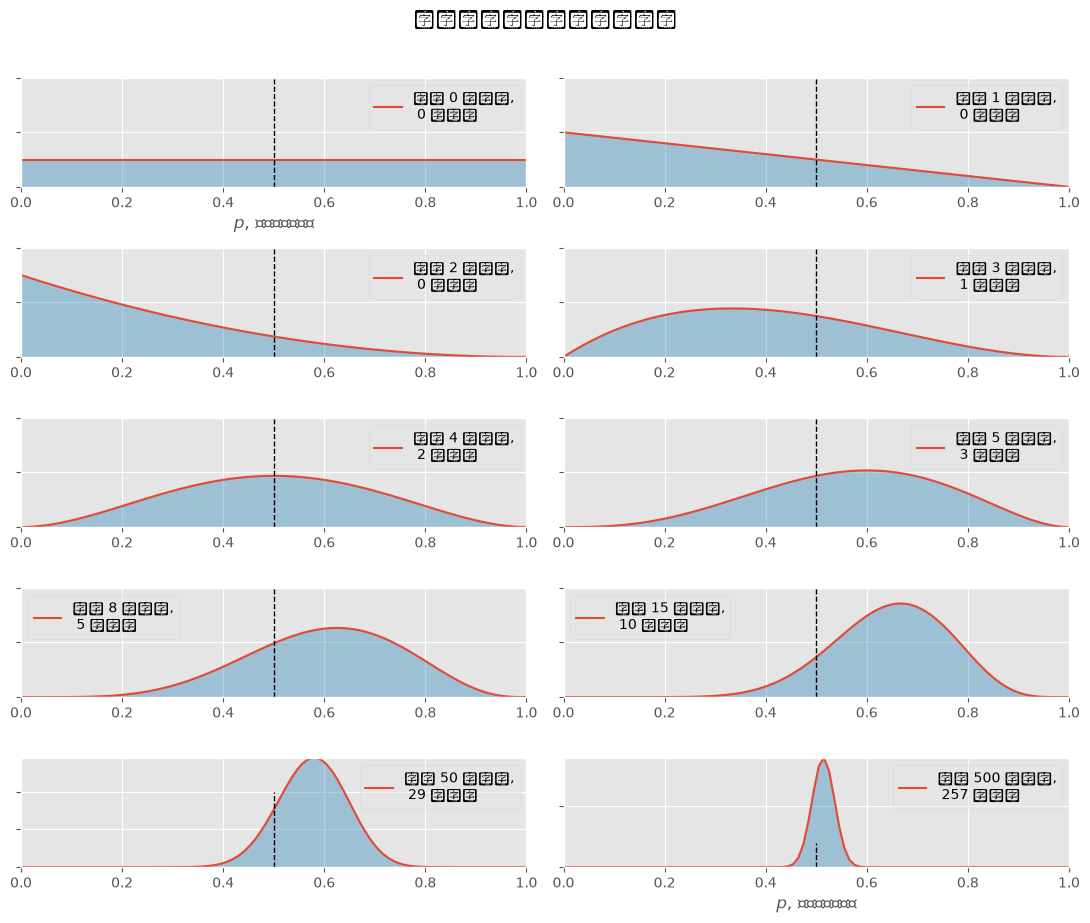

In [1]:

'''
本书使用了一个自定义的 matplotlibrc 文件,用来提供书中独特的 matplotlib 绘图风格。
如果你在运行本书代码时也想使用这套风格,有两种方式:
    1. 用书中 styles/ 目录下提供的 rc 文件覆盖你自己的 matplotlibrc 文件。
       参见 http://matplotlib.org/users/customizing.html
    2. styles/ 目录下也有一个 bmh_matplotlibrc.json 文件,可以只在当前 notebook
       中更新样式,试试运行下面的代码:

        import json
        s = json.load(open("../styles/bmh_matplotlibrc.json"))
        matplotlib.rcParams.update(s)
'''

# 下面这段代码可以先跳过不看,因为暂时不重要,而且用到了我们还没讲过的高级内容。
# 先看图就好!
%matplotlib inline
from IPython.core.pylabtools import figsize
import numpy as np
from matplotlib import pyplot as plt
import matplotlib as mpl
mpl.style.use("ggplot")
figsize(11, 9)

import scipy.stats as stats

dist = stats.beta
n_trials = [0, 1, 2, 3, 4, 5, 8, 15, 50, 500]
data = stats.bernoulli.rvs(0.5, size=n_trials[-1])
x = np.linspace(0, 1, 100)

# 对已经熟悉的读者说明: 这里用的是二项分布的共轭先验 (Beta 分布)。
for k, N in enumerate(n_trials):
    sx = plt.subplot(len(n_trials)//2, 2, k+1)
    plt.xlabel("$p$, 正面朝上的概率") \
        if k in [0, len(n_trials)-1] else None
    plt.setp(sx.get_yticklabels(), visible=False)
    heads = data[:N].sum()
    y = dist.pdf(x, 1 + heads, 1 + N - heads)
    plt.plot(x, y, label="观测 %d 次抛掷,\n %d 次正面" % (N, heads))
    plt.fill_between(x, 0, y, color="#348ABD", alpha=0.4)
    plt.vlines(0.5, 0, 4, color="k", linestyles="--", lw=1)

    leg = plt.legend()
    leg.get_frame().set_alpha(0.4)
    plt.autoscale(tight=True)


plt.suptitle("后验概率的贝叶斯更新过程",
             y=1.02,
             fontsize=14)

plt.tight_layout()



图中的曲线代表后验概率,曲线的宽度则正比于我们的不确定性。从上图可以看出,一旦我们开始观测数据,后验概率就会开始变化、移动。最终,随着我们观测到越来越多的数据(抛硬币次数),我们的概率会越来越紧密地收拢在 $p=0.5$ 这个真实值附近(图中虚线标出)。

注意,这些曲线并不总是在 0.5 处达到峰值。这本来就不该如此:回想一下,我们假设自己对 $p$ 到底是多少并没有先验意见。事实上,如果我们观测到相当极端的数据,比如抛了 8 次只观测到 1 次正面,那么分布看起来就会明显偏离 0.5(在没有先验意见的情况下,观测到 8 次反面、1 次正面之后,你会有多大信心去赌这是一枚均匀硬币呢?)。随着数据不断积累,我们会看到越来越多的概率被分配到 $p=0.5$ 附近,尽管永远不会是全部。

下一个例子将简单展示贝叶斯推断背后的数学过程。



##### 示例:是 bug,还是"甜蜜的意外特性"?

记 $A$ 为"我们的代码**没有 bug**"这一事件。记 $X$ 为"代码通过了全部调试测试"这一事件。现在,我们暂且把"没有 bug"的先验概率留作一个变量,即 $P(A) = p$。

我们关心的是 $P(A \mid X)$,也就是在通过调试测试 $X$ 之后,代码没有 bug 的概率。要用上面的公式,我们需要先算出几个量。

$P(X \mid A)$ 是多少,也就是说,*假设*代码没有 bug,它通过 $X$ 项测试的概率是多少?这个很简单,等于 1,因为没有 bug 的代码理应通过所有测试。

$P(X)$ 就稍微复杂一点了:事件 $X$ 可以拆分成两种可能性——代码*确实有* bug 但仍然出现了事件 $X$(记作 $\sim A$,读作"非 $A$"),或者代码没有 bug 时出现了事件 $X$($A$)。于是 $P(X)$ 可以表示为:



\begin{align}
P(X ) & = P(X \text{ 且 } A) + P(X \text{ 且 } \sim A) \\\\[5pt]
 & = P(X|A)P(A) + P(X | \sim A)P(\sim A)\\\\[5pt]
& = P(X|A)p + P(X | \sim A)(1-p)
\end{align}



上面我们已经算出了 $P(X \mid A)$。另一方面,$P(X \mid \sim A)$ 则是主观的:代码可能通过了测试却仍然存在 bug,只不过存在 bug 的概率有所降低。注意这个值取决于测试的数量、测试的复杂程度等因素。我们保守一点,取 $P(X \mid \sim A) = 0.5$。于是有

\begin{align}
P(A | X) & = \frac{1\cdot p}{ 1\cdot p +0.5 (1-p) } \\\\
& = \frac{ 2 p}{1+p}
\end{align}

这就是后验概率。作为先验 $p \in [0,1]$ 的函数,它长什么样呢?


Font 'default' does not have a glyph for '\u540e' [U+540e], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u9a8c' [U+9a8c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5176' [U+5176], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u4e2d' [U+4e2d], substituting with a dummy symbol.


/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 25105 (\N{CJK UNIFIED IDEOGRAPH-6211}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 20195 (\N{CJK UNIFIED IDEOGRAPH-4EE3}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 30721 (\N{CJK UNIFIED IDEOGRAPH-7801}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 37324 (\N{CJK UNIFIED IDEOGRAPH-91CC}) missing from font(s) DejaVu Sans.
  func(*args, **kwa

...

Font 'default' does not have a glyph for '\u5176' [U+5176], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u4e2d' [U+4e2d], substituting with a dummy symbol.


/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 25105 (\N{CJK UNIFIED IDEOGRAPH-6211}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20195 (\N{CJK UNIFIED IDEOGRAPH-4EE3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 30721 (\N{CJK UNIFIED IDEOGRAPH-7801}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 37324 (\N{CJK UNIFIED IDEOGRAPH-91CC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 

Font 'default' does not have a glyph for '\u5148' [U+5148], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u9a8c' [U+9a8c], substituting with a dummy symbol.


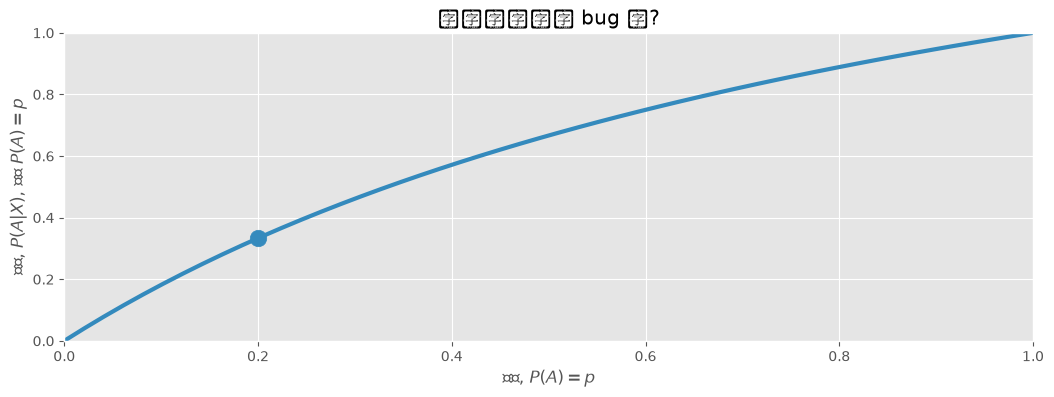

In [2]:

figsize(12.5, 4)
p = np.linspace(0, 1, 50)
plt.plot(p, 2*p/(1+p), color="#348ABD", lw=3)
# plt.fill_between(p, 2*p/(1+p), alpha=.5, facecolor=["#A60628"])
plt.scatter(0.2, 2*(0.2)/1.2, s=140, c="#348ABD")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("先验, $P(A) = p$")
plt.ylabel("后验, $P(A|X)$, 其中 $P(A) = p$")
plt.title("我的代码里有 bug 吗?");



可以看到,当先验概率 $p$ 较低时,一旦观测到 $X$ 项测试全部通过,我们获得的信念提升是最大的。让我们为先验定一个具体的数值。我自认为是个比较靠谱的程序员,所以给自己一个比较现实的先验:0.20,也就是说,我写出没有 bug 的代码的概率是 20%。更严谨地说,这个先验其实应该是代码复杂程度和规模的函数,但这里我们就先固定在 0.20。那么在更新之后,我相信代码没有 bug 的信念就变成了 0.33。

回忆一下,先验本身也是一个概率:$p$ 是"没有 bug"的先验概率,所以 $1-p$ 就是"存在 bug"的先验概率。

同理,后验也是一个概率,$P(A \mid X)$ 是在*观测到全部测试通过*的条件下"没有 bug"的概率,因此 $1-P(A \mid X)$ 就是"存在 bug"的概率。我们的后验概率长什么样呢?下面是先验和后验概率的对比图。


/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 26080 (\N{CJK UNIFIED IDEOGRAPH-65E0}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  func(*args, **kwa

/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missi

/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


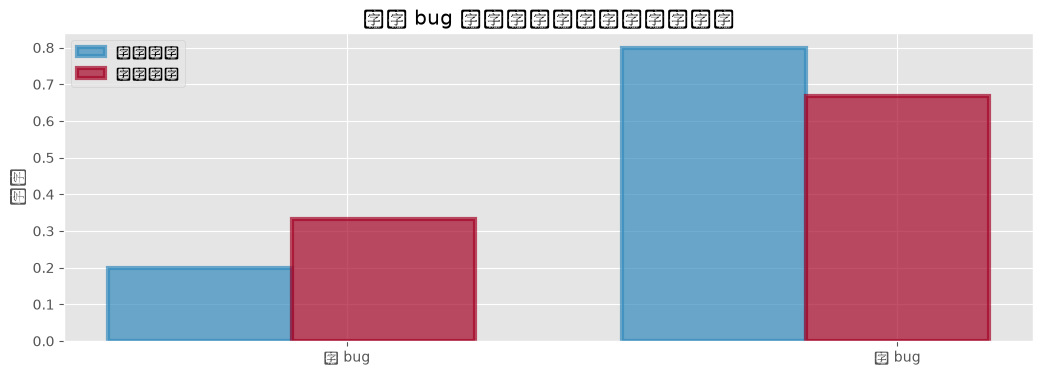

In [3]:

figsize(12.5, 4)
colours = ["#348ABD", "#A60628"]

prior = [0.20, 0.80]
posterior = [1./3, 2./3]
plt.bar([0, .7], prior, alpha=0.70, width=0.25,
        color=colours[0], label="先验分布",
        lw="3", edgecolor=colours[0])

plt.bar([0+0.25, .7+0.25], posterior, alpha=0.7,
        width=0.25, color=colours[1],
        label="后验分布",
        lw="3", edgecolor=colours[1])

plt.xticks([0.20, .95], ["无 bug", "有 bug"])
plt.title("有无 bug 的先验概率与后验概率对比")
plt.ylabel("概率")
plt.legend(loc="upper left");



注意到,在我们观测到 $X$ 发生之后,"没有 bug"的概率增加了。随着测试数量的增加,我们可以逐渐逼近对"没有 bug"这件事的绝对信心(概率为 1)。

这只是贝叶斯推断和贝叶斯法则的一个非常简单的例子。遗憾的是,除了少数人为构造的特殊情形,更复杂的贝叶斯推断所需要的数学只会变得越来越棘手。我们后面会看到,这种纯数学分析其实是完全没有必要的——但在此之前,我们首先要拓宽自己的建模工具箱。下一节将讨论*概率分布*。如果你已经熟悉这部分内容,可以跳过(或者简单浏览一下),但对不太熟悉的读者来说,下一节的内容是必不可少的。



_______

## 概率分布

**让我们先快速回顾一下什么是概率分布:** 设 $Z$ 是某个随机变量。与 $Z$ 相关联的是一个*概率分布函数*,它为 $Z$ 可能取到的各种结果分配概率。从图形上看,概率分布是一条曲线,某个结果的概率正比于曲线在该处的高度。本章第一幅图就是一个例子。

我们可以把随机变量分为三类:

- **$Z$ 是离散的**:离散随机变量只能取一份指定列表中的值。人口数量、电影评分、投票数这些都是离散随机变量。当我们把离散随机变量和下面这种类型对比时,它的含义会更清晰……

- **$Z$ 是连续的**:连续随机变量可以取任意精确的值。例如温度、速度、时间、颜色,都被建模为连续变量,因为你总是可以让这些值变得越来越精确。

- **$Z$ 是混合的**:混合随机变量同时把概率分配给离散和连续两部分取值,也就是上面两种类型的组合。

### 离散情形

如果 $Z$ 是离散的,它的分布就被称为*概率质量函数*(probability mass function),用来衡量 $Z$ 取值为 $k$ 的概率,记作 $P(Z=k)$。注意,概率质量函数完全刻画了随机变量 $Z$——也就是说,只要知道了质量函数,我们就知道 $Z$ 该如何"表现"。有一些常见的概率质量函数会反复出现,我们会在需要的时候逐一介绍,先来看第一个非常有用的概率质量函数。如果满足下式,我们就说 $Z$ 服从*泊松(Poisson)*分布:

$$P(Z = k) =\frac{ \lambda^k e^{-\lambda} }{k!}, \; \; k=0,1,2, \dots $$

$\lambda$ 被称为该分布的一个参数,它控制着分布的形状。对泊松分布来说,$\lambda$ 可以是任意正数。增大 $\lambda$ 会给更大的取值分配更多概率,反之减小 $\lambda$ 则会把更多概率分配给较小的取值。我们可以把 $\lambda$ 理解为泊松分布的"强度"。

和可以取任意正数的 $\lambda$ 不同,上式中的 $k$ 必须是非负整数,即 $k$ 只能取 0, 1, 2, ⋯ 这样的值。这一点非常重要,因为如果你想为人口建模,一个"4.25 人"或"5.612 人"的人口数是没有意义的。

如果随机变量 $Z$ 服从泊松质量分布,我们记作

$$Z \sim \text{Poi}(\lambda) $$

泊松分布有一个很有用的性质:它的期望值恰好等于它的参数,即:

$$E\large[ \;Z\; | \; \lambda \;\large] = \lambda $$

我们以后会经常用到这个性质,值得记住。下面我们画出不同 $\lambda$ 取值下的概率质量分布。首先可以注意到,增大 $\lambda$ 会给更大的取值分配更多概率。其次,虽然图形在 15 处截断了,但分布本身并不会在那里终止——它们会为每一个非负整数都分配一个大于零的概率。


<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2880226/3963047152.py:10: SyntaxWarning: invalid escape sequence '\l'
  label="$\lambda = %.1f$" % lambda_[0], alpha=0.60,
/tmp/ipykernel_2880226/3963047152.py:14: SyntaxWarning: invalid escape sequence '\l'
  label="$\lambda = %.1f$" % lambda_[1], alpha=0.60,
/tmp/ipykernel_2880226/3963047152.py:21: SyntaxWarning: invalid escape sequence '\l'
  plt.title("泊松随机变量的概率质量函数;不同 \
Font 'default' does not have a glyph for '\u53d6' [U+53d6], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u503c' [U+503c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u4e3a' [U+4e3a], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7684' [U+7684], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6982' [U+6982], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u53d6' [U+53d6], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u503c' [U+503c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u4e0b' [U+4e0b], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5bf9' [U+5bf9], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6bd4' [U+6bd4], substituting with a dummy symbol.


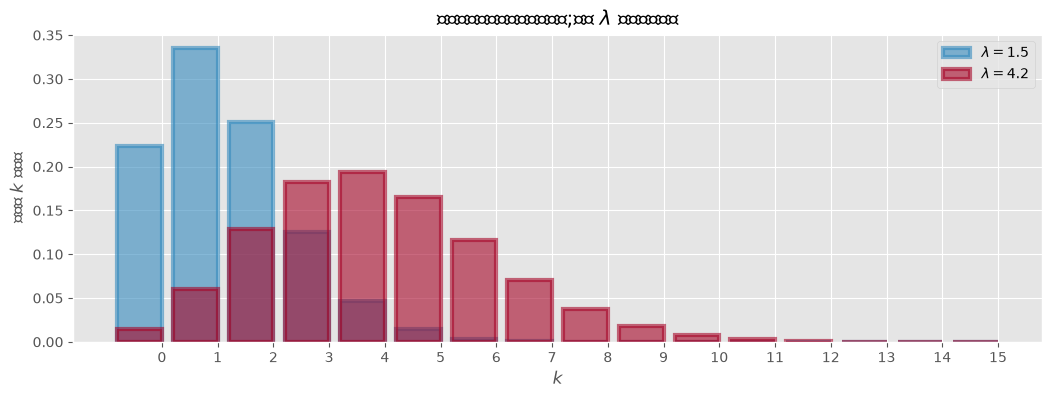

In [4]:

figsize(12.5, 4)

import scipy.stats as stats
a = np.arange(16)
poi = stats.poisson
lambda_ = [1.5, 4.25]
colours = ["#348ABD", "#A60628"]

plt.bar(a, poi.pmf(a, lambda_[0]), color=colours[0],
        label="$\lambda = %.1f$" % lambda_[0], alpha=0.60,
        edgecolor=colours[0], lw="3")

plt.bar(a, poi.pmf(a, lambda_[1]), color=colours[1],
        label="$\lambda = %.1f$" % lambda_[1], alpha=0.60,
        edgecolor=colours[1], lw="3")

plt.xticks(a + 0.4, a)
plt.legend()
plt.ylabel("取值为 $k$ 的概率")
plt.xlabel("$k$")
plt.title("泊松随机变量的概率质量函数;不同 \
$\lambda$ 取值下的对比");



### 连续情形

连续随机变量对应的不是概率质量函数,而是*概率密度函数*。这可能看起来只是换了个名词而已,但密度函数和质量函数其实是两种截然不同的"生物"。一个连续随机变量的例子是服从*指数分布*的随机变量。指数分布随机变量的密度函数长这样:

$$f_Z(z | \lambda) = \lambda e^{-\lambda z }, \;\; z\ge 0$$

和泊松随机变量一样,指数随机变量也只能取非负值。但和泊松变量不同的是,指数变量可以取*任意*非负值,包括像 4.25 或 5.612401 这样的非整数值。这个性质使得指数分布不适合用来为"计数"数据建模(计数必须是整数),但却非常适合用来为时间数据、温度数据(当然要用开尔文计量)或其他任何精确的*正值*变量建模。下图展示了两条参数不同的概率密度函数曲线。

当随机变量 $Z$ 服从参数为 $\lambda$ 的指数分布时,我们说 *$Z$ 是指数分布的*,记作

$$Z \sim \text{Exp}(\lambda)$$

给定具体的 $\lambda$,指数随机变量的期望值等于 $\lambda$ 的倒数,即:

$$E[\; Z \;|\; \lambda \;] = \frac{1}{\lambda}$$


<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2880226/872590186.py:7: SyntaxWarning: invalid escape sequence '\l'
  color=c, label="$\lambda = %.1f$" % l)
/tmp/ipykernel_2880226/872590186.py:14: SyntaxWarning: invalid escape sequence '\l'
  plt.title("指数随机变量的概率密度函数;\


Font 'default' does not have a glyph for '\u5904' [U+5904], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7684' [U+7684], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6982' [U+6982], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7387' [U+7387], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u53d6' [U+53d6], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u503c' [U+503c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u4e0b' [U+4e0b], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5bf9' [U+5bf9], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6bd4' [U+6bd4], substituting with a dummy symbol.


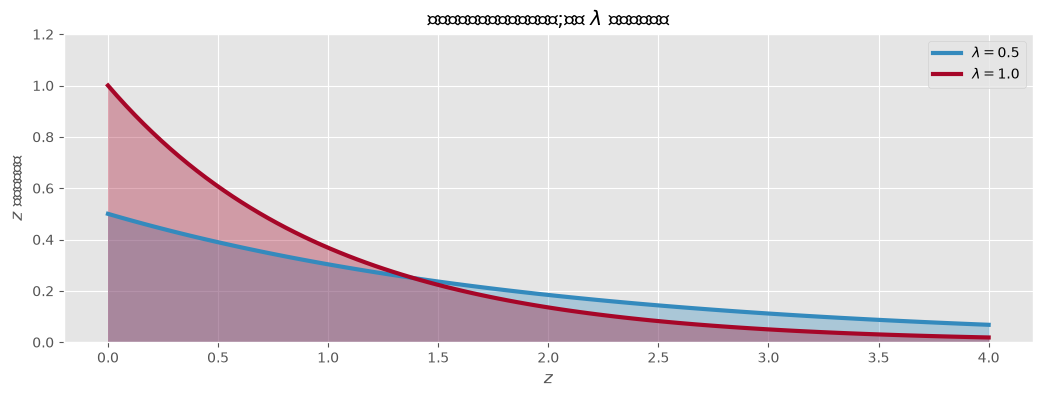

In [5]:

a = np.linspace(0, 4, 100)
expo = stats.expon
lambda_ = [0.5, 1]

for l, c in zip(lambda_, colours):
    plt.plot(a, expo.pdf(a, scale=1./l), lw=3,
             color=c, label="$\lambda = %.1f$" % l)
    plt.fill_between(a, expo.pdf(a, scale=1./l), color=c, alpha=.33)

plt.legend()
plt.ylabel("$z$ 处的概率密度")
plt.xlabel("$z$")
plt.ylim(0, 1.2)
plt.title("指数随机变量的概率密度函数;\
不同 $\lambda$ 取值下的对比");



### 但 $\lambda$ 到底是什么?

**这个问题正是统计学存在的动机所在。** 在现实世界中,$\lambda$ 对我们是隐藏的,我们只能看到 $Z$,却必须反过来推断出 $\lambda$。这个问题之所以困难,是因为从 $Z$ 到 $\lambda$ 并不存在一一对应的映射关系。人们已经发明了许多方法来解决估计 $\lambda$ 的问题,但由于 $\lambda$ 从来都不会被直接观测到,也就没有人能斩钉截铁地说哪种方法才是"最好的"!

贝叶斯推断关心的是关于 $\lambda$ 可能是什么的*信念*。与其试图精确地猜出 $\lambda$,我们只能通过为 $\lambda$ 赋予一个概率分布,来谈论 $\lambda$ 更可能是什么。

乍一看这可能有点奇怪。毕竟 $\lambda$ 是固定的,它(至少不必然)是随机的!我们怎么能给一个非随机变量的取值赋予概率呢?啊,我们又不小心掉回了老旧的频率学派思维模式。回忆一下,在贝叶斯哲学下,只要我们把概率解读为信念,就*完全可以*赋予概率。而对参数 $\lambda$ 持有*信念*,这本身是完全站得住脚的。



##### 示例:从短信数据中推断用户行为

让我们来尝试建模一个更有意思的例子,关于一个用户发送和接收短信的*频率*:

> 给你一份用户每日短信条数的时间序列数据。把数据随时间画出来,如下图所示。你很好奇,这位用户的短信习惯是否随着时间发生了变化,不管是渐变还是突变。你要如何为这个问题建模呢?(这其实是我自己的短信数据,我的"受欢迎程度"就随你评判吧。)


/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 24403 (\N{CJK UNIFIED IDEOGRAPH-5F53}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 21040 (\N{CJK UNIFIED IDEOGRAPH-5230}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  func(*args, **kwa

/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 24403 (\N{CJK UNIFIED IDEOGRAPH-5F53}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 21040 (\N{CJK UNIFIED IDEOGRAPH-5230}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 

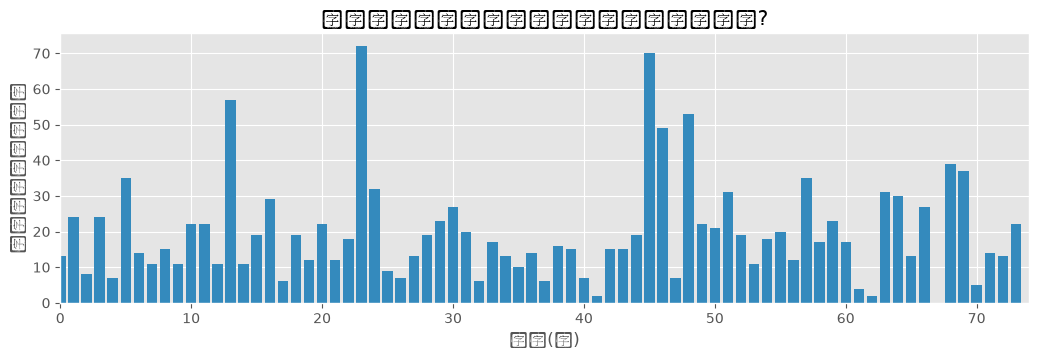

In [6]:

figsize(12.5, 3.5)
count_data = np.loadtxt("data/txtdata.csv")
n_count_data = len(count_data)
plt.bar(np.arange(n_count_data), count_data, color="#348ABD")
plt.xlabel("时间(天)")
plt.ylabel("当天收到的短信条数")
plt.title("这位用户的短信习惯是否随时间发生了变化?")
plt.xlim(0, n_count_data);



在我们开始建模之前,不妨先看看仅凭上面这张图,你能看出些什么。你觉得在这段时间里,用户的行为是否发生了变化?

我们要如何开始为它建模呢?正如我们刚刚方便地学到的那样,泊松随机变量非常适合为这种*计数*类型的数据建模。记第 $i$ 天的短信条数为 $C_i$,

$$ C_i \sim \text{Poisson}(\lambda)  $$

不过,我们并不确定参数 $\lambda$ 的真实值是多少。观察上图会发现,在观测期后段,短信频率似乎变高了,这等价于说 $\lambda$ 在观测期内的某个时间点发生了增大(回忆一下,更大的 $\lambda$ 会为较大的结果分配更多概率——也就是说,某一天发送大量短信的概率更高)。

我们要如何用数学语言来表达这个观察呢?假设在观测期内的某一天(记作 $\tau$),参数 $\lambda$ 突然跳变到了一个更高的值。所以我们实际上有两个 $\lambda$ 参数:一个用于 $\tau$ 之前的时期,另一个用于观测期剩下的时间。在文献中,这种突然的转变被称为*切换点*(switchpoint):

$$
\lambda =
\begin{cases}
\lambda_1  & \text{if } t \lt \tau \cr
\lambda_2 & \text{if } t \ge \tau
\end{cases}
$$

如果实际上并没有发生突然的变化,即 $\lambda_1 = \lambda_2$ 确实成立,那么两个 $\lambda$ 的后验分布应该看起来大致相同。

我们感兴趣的是推断出未知的 $\lambda$ 值。要使用贝叶斯推断,我们需要为 $\lambda$ 可能的不同取值赋予先验概率。$\lambda_1$ 和 $\lambda_2$ 分别用什么先验分布比较合适呢?回忆一下,$\lambda$ 可以是任意正数。正如我们前面看到的,*指数*分布为正数提供了一个连续的密度函数,所以它可能是为 $\lambda_i$ 建模的一个不错的选择。但别忘了指数分布本身也带有一个参数,所以我们需要把这个参数也纳入模型。我们把这个参数记为 $\alpha$。

\begin{align}
&\lambda_1 \sim \text{Exp}( \alpha ) \\\
&\lambda_2 \sim \text{Exp}( \alpha )
\end{align}

$\alpha$ 被称为*超参数*(hyper-parameter)或者*父变量*(parent variable)。字面意思上,它是一个会影响其他参数的参数。我们对 $\alpha$ 的初始猜测对模型的影响并不算太大,所以在选择上我们有一定的灵活性。一个不错的经验法则是,把指数分布的参数设为计数数据平均值的倒数。既然我们用指数分布为 $\lambda$ 建模,就可以借助前面提到的期望值恒等式得到:

$$\frac{1}{N}\sum_{i=0}^N \;C_i \approx E[\; \lambda \; |\; \alpha ] = \frac{1}{\alpha}$$

另一种做法(也鼓励读者自己尝试)是为两个 $\lambda_i$ 各自设置一个先验。用不同的 $\alpha$ 值构造两个不同的指数分布,可以反映我们"速率在观测期内某个时刻发生了变化"这一先验信念。

那 $\tau$ 呢?由于数据本身存在噪声,很难先验地判断 $\tau$ 具体发生在哪一天。所以我们可以为每一个可能的天数赋予一个*均匀的先验信念*。这等价于说

\begin{align}
& \tau \sim \text{DiscreteUniform(1,70) }\\\\
& \Rightarrow P( \tau = k ) = \frac{1}{70}
\end{align}

经过这一番折腾之后,我们对未知变量的整体先验分布长什么样呢?坦白讲,*这并不重要*。我们应该明白的是,这会是一团丑陋、复杂的、只有数学家才会喜欢的符号堆砌。而且随着模型变得越来越复杂,情况只会变得更丑。不管怎样,我们真正在乎的,始终是后验分布。

接下来,我们要请出 PyMC——一个用于执行贝叶斯分析的 Python 库,它完全不会被我们刚刚制造出来的数学"怪物"吓倒。

## 请出我们的第一件趁手工具:PyMC

PyMC 是一个用于贝叶斯分析编程的 Python 库 [3]。它速度快,维护良好。唯一美中不足的是,它的文档在某些方面还有所欠缺,尤其是在"新手"和"老手"之间的过渡阶段。本书的主要目标之一,就是解决这个问题,同时也展示 PyMC 到底有多酷。

我们将用 PyMC 为上面的问题建模。这类编程被称为*概率编程*(probabilistic programming),这个名字其实起得不太好,容易让人联想到"随机生成的代码",从而把不少人吓跑、劝退。但代码本身并不是随机的;它之所以是"概率的",是因为我们用编程变量作为模型的组件来构建概率模型。模型组件在 PyMC 框架中是一等公民(first-class primitives)。

B. Cronin [5] 对概率编程有一段非常有启发性的描述:

> 换一种思路来理解:和只能向前运行的传统程序不同,概率程序会同时向前和向后运行。它向前运行,以计算出其中所包含的关于世界的假设(也就是它所代表的模型空间)会带来什么后果;但它也会从数据反向运行,以约束可能的解释空间。在实践中,许多概率编程系统会巧妙地交替进行这种正向和反向操作,从而高效地逼近出最佳解释。

由于"概率编程"这个术语容易引起误解,我会尽量避免使用它。我会简单地把它称作*编程*,因为这就是它的本质。

PyMC 的代码很容易读懂,唯一算得上新鲜的地方是语法本身。只需记住,我们是在用变量表示模型的各个组件($\tau, \lambda_1, \lambda_2$)。

**关于本中文·现代 PyMC 版的一点补充说明**:原书写作时,PyMC 还处于第 2/3 代,`import pymc3 as pm` 是当年的标准写法。今天(PyMC 5/6.x)统一使用 `import pymc as pm`,并且默认返回的采样结果是基于 `arviz` 的 `InferenceData`(而不是旧版的 `MultiTrace`)。这两点本书后续所有章节都会保持一致——这也是这个中文 fork 相对英文原版最主要的技术改动之一。


In [7]:

import pymc as pm

with pm.Model() as model:
    alpha = 1.0 / count_data.mean()  # 回忆一下, count_data 就是保存
                                      # 短信条数的那个变量
    lambda_1 = pm.Exponential("lambda_1", alpha)
    lambda_2 = pm.Exponential("lambda_2", alpha)

    tau = pm.DiscreteUniform("tau", lower=0, upper=n_count_data - 1)



在上面的代码中,我们创建了对应 $\lambda_1$ 和 $\lambda_2$ 的 PyMC 变量。我们把它们赋值为 PyMC 的*随机变量*(stochastic variable),之所以叫这个名字,是因为在底层它们会被当作随机数生成器来处理。


In [8]:

with model:
    idx = np.arange(n_count_data)  # 索引
    lambda_ = pm.math.switch(tau > idx, lambda_1, lambda_2)



这段代码创建了一个新的函数 `lambda_`,但我们其实可以把它想象成一个随机变量:也就是上面提到的随机变量 $\lambda$。`switch()` 函数会根据我们处在 `tau` 的哪一侧,把 `lambda_1` 或 `lambda_2` 的值赋给 `lambda_`。`tau` 之前的 `lambda_` 值是 `lambda_1`,之后的值则是 `lambda_2`。

注意,由于 `lambda_1`、`lambda_2` 和 `tau` 都是随机的,`lambda_` 自然也是随机的。**我们目前还没有固定任何变量。**


In [9]:

with model:
    observation = pm.Poisson("obs", lambda_, observed=count_data)



变量 `observation` 通过 `observed` 这个关键字参数,把我们的数据 `count_data` 和我们提出的数据生成机制(由变量 `lambda_` 给出)结合了起来。

下面这段代码会在第三章详细解释,这里先展示出来,让你能看到我们的结果究竟是怎么来的。可以把它想象成一个*学习*步骤。这里用到的机制叫做*马尔可夫链蒙特卡洛*(Markov Chain Monte Carlo, MCMC),同样会留到第三章详细解释。这项技术会从 $\lambda_1$、$\lambda_2$ 和 $\tau$ 的后验分布中返回成千上万个随机变量。我们可以把这些随机变量画成直方图,看看后验分布长什么样。下面,我们把这些采样得到的样本(在 MCMC 文献中称为*轨迹*, trace)收集起来做成直方图。

**现代 PyMC 小贴士**:`pm.sample()` 现在默认返回一个 `arviz.InferenceData` 对象(`idata`),而不是原书使用的旧式 `MultiTrace`。`InferenceData` 内部用 `xarray` 组织数据,维度包括 `chain`(第几条 MCMC 链)和 `draw`(链内第几个样本),访问某个变量的全部样本要写成 `idata.posterior["变量名"]`。我们在下面沿用这个现代写法,这样也顺便为第三章要讲的 MCMC/`arviz` 内容打个前站。


In [10]:

### 神秘代码,将在第三章详细解释。
with model:
    step = pm.Metropolis()
    idata = pm.sample(10000, tune=5000, step=step)


Multiprocess sampling (2 chains in 2 jobs)


CompoundStep


>Metropolis: [lambda_1]


>Metropolis: [lambda_2]


>Metropolis: [tau]


Output()

Sampling 2 chains for 5_000 tune and 10_000 draw iterations (10_000 + 20_000 draws total) took 27 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


In [11]:

# 现代写法: 从 idata.posterior (一个 xarray.Dataset) 里取出后验样本,
# 并把 (chain, draw) 两个维度合并展平成一维的"样本"序列,
# 这样后面画直方图时就不用关心究竟用了几条链。
lambda_1_samples = idata.posterior["lambda_1"].values.flatten()
lambda_2_samples = idata.posterior["lambda_2"].values.flatten()
tau_samples = idata.posterior["tau"].values.flatten()


<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2880226/2234204813.py:8: SyntaxWarning: invalid escape sequence '\l'
  label="$\lambda_1$ 的后验分布", color="#A60628", density=True)
/tmp/ipykernel_2880226/2234204813.py:12: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("$\lambda_1$ 的取值")
/tmp/ipykernel_2880226/2234204813.py:17: SyntaxWarning: invalid escape sequence '\l'
  label="$\lambda_2$ 的后验分布", color="#7A68A6", density=True)
/tmp/ipykernel_2880226/2234204813.py:20: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("$\lambda_2$ 的取值")


Font 'default' does not have a glyph for '\u53d8' [U+53d8], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u91cf' [U+91cf], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7684' [U+7684], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u540e' [U+540e], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u7684' [U+7684], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u540e' [U+540e], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u9a8c' [U+9a8c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5206' [U+5206], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5e03' [U+5e03], substituting with a dummy symbol.


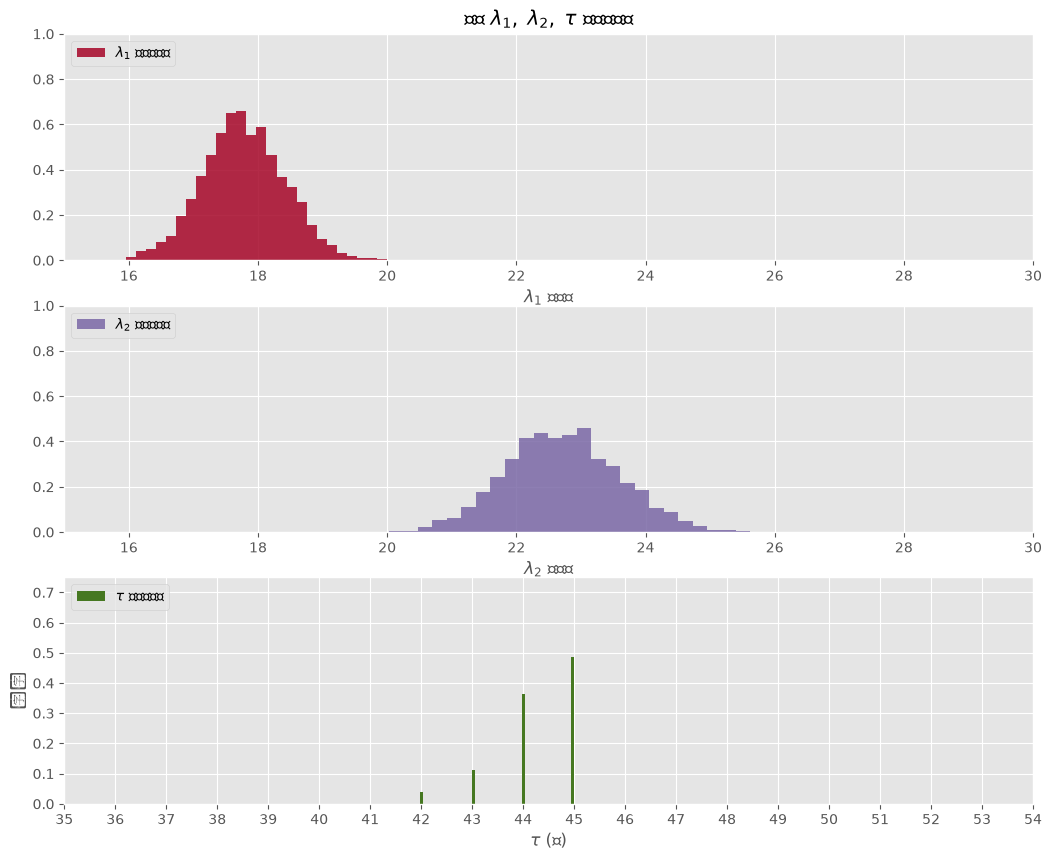

In [12]:

figsize(12.5, 10)
# 样本的直方图:

ax = plt.subplot(311)
ax.set_autoscaley_on(False)

plt.hist(lambda_1_samples, histtype='stepfilled', bins=30, alpha=0.85,
         label="$\lambda_1$ 的后验分布", color="#A60628", density=True)
plt.legend(loc="upper left")
plt.title(r"变量 $\lambda_1,\;\lambda_2,\;\tau$ 的后验分布")
plt.xlim([15, 30])
plt.xlabel("$\lambda_1$ 的取值")

ax = plt.subplot(312)
ax.set_autoscaley_on(False)
plt.hist(lambda_2_samples, histtype='stepfilled', bins=30, alpha=0.85,
         label="$\lambda_2$ 的后验分布", color="#7A68A6", density=True)
plt.legend(loc="upper left")
plt.xlim([15, 30])
plt.xlabel("$\lambda_2$ 的取值")

plt.subplot(313)
w = 1.0 / tau_samples.shape[0] * np.ones_like(tau_samples)
plt.hist(tau_samples, bins=n_count_data, alpha=1,
         label=r"$\tau$ 的后验分布",
         color="#467821", weights=w, rwidth=2.)
plt.xticks(np.arange(n_count_data))

plt.legend(loc="upper left")
plt.ylim([0, .75])
plt.xlim([35, len(count_data)-20])
plt.xlabel(r"$\tau$ (天)")
plt.ylabel("概率");



### 小结:现代 PyMC 的收敛性诊断(原书没有的补充内容)

在原书写作的年代(PyMC2/3),检查 MCMC 是否"采样得靠谱"往往依赖手工画图、凭经验判断。今天 `arviz` 提供了一套标准化的诊断工具,`az.summary()` 能一次性给出每个参数的后验均值、标准差、可信区间,以及两个关键的收敛性指标:

- **`r_hat`**:应当接近 1.00。如果明显大于 1(比如超过 1.01),说明不同链之间还没有收敛到同一个分布,采样结果不可信。
- **`ess_bulk`** (有效样本量):数值越大越好,太小(比如只有几十)说明链内自相关严重,后验估计的蒙特卡洛误差可能偏大。

这两个指标会在第三章详细展开,这里只是先"露个脸",让你知道除了肉眼看直方图,还有更严谨的定量方式来判断 MCMC 结果是否值得信任。


In [13]:

import arviz as az

az.summary(idata, var_names=["lambda_1", "lambda_2", "tau"])


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lambda_1,17.776,0.635,16.588,18.986,0.011,0.008,3286.0,3934.0,1.0
lambda_2,22.712,0.877,21.194,24.496,0.015,0.011,3370.0,3458.0,1.0
tau,44.293,0.820,43.000,45.000,0.015,0.011,2826.0,3057.0,1.0



### 结果解读

回忆一下,贝叶斯方法给出的是一个*分布*。所以现在我们得到的是描述未知量 $\lambda$ 和 $\tau$ 的分布。我们从中得到了什么呢?首先,我们可以直接看出估计的不确定性:分布越宽,后验信念就应该越不确定。我们还可以看出参数的合理取值范围大致是多少:$\lambda_1$ 大约在 18 附近,$\lambda_2$ 大约在 23 附近。两个 $\lambda$ 的后验分布明显是分开的,这说明用户的短信行为确实很可能发生过变化。

你还能观察到什么别的现象吗?如果你再回头看看原始数据,这些结果看起来合理吗?

还要注意到,尽管我们给这两个 $\lambda$ 变量设置的先验都是指数分布,但它们的后验分布看起来完全不像指数分布。事实上,这些后验分布并不属于我们从原始模型中能一眼认出的任何标准分布族。但这没关系!这正是采用计算视角带来的好处之一。如果我们是靠纯数学方法来做这个分析,那我们很可能会被一个解析上难以处理(而且形式丑陋)的分布卡住。而计算方法则让我们完全不必在意数学上是否"可解"。

我们的分析同时也给出了 $\tau$ 的分布。它的后验分布看起来和另外两个略有不同,因为它是一个离散随机变量,所以并不会给"区间"赋予概率。可以看到,在第 45 天附近,用户行为发生变化的可能性大约是 50%。如果没有发生变化,或者变化是随着时间逐渐发生的,那么 $\tau$ 的后验分布应该会更加分散,反映出许多天都是 $\tau$ 的合理候选。相比之下,在我们实际得到的结果里,只有三四天称得上是有意义的潜在转折点。



### 那为什么我要费这么大劲从后验里取样呢?

我们会在本书余下的部分不断回到这个问题,可以毫不夸张地说,它会引领我们得到一些非常精彩的结果。现在,让我们用再一个例子来结束本章。

我们会用后验样本来回答下面这个问题:在第 $t$ 天($0 \le t \le 70$),预期的短信条数是多少?回忆一下,泊松变量的期望值恰好等于它的参数 $\lambda$。所以这个问题其实等价于:*在时刻 $t$,$\lambda$ 的期望值是多少*?

在下面的代码里,记 $i$ 为后验分布样本的索引。给定某一天 $t$,我们对这一天所有可能的 $\lambda_i$ 取平均:如果 $t \lt \tau_i$(也就是说,行为变化还没有发生),就用 $\lambda_i = \lambda_{1,i}$;否则用 $\lambda_i = \lambda_{2,i}$。


/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 30701 (\N{CJK UNIFIED IDEOGRAPH-77ED}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 20449 (\N{CJK UNIFIED IDEOGRAPH-4FE1}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 26465 (\N{CJK UNIFIED IDEOGRAPH-6761}) missing from font(s) DejaVu Sans.
  func(*args, **kwa

/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 30701 (\N{CJK UNIFIED IDEOGRAPH-77ED}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20449 (\N{CJK UNIFIED IDEOGRAPH-4FE1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 

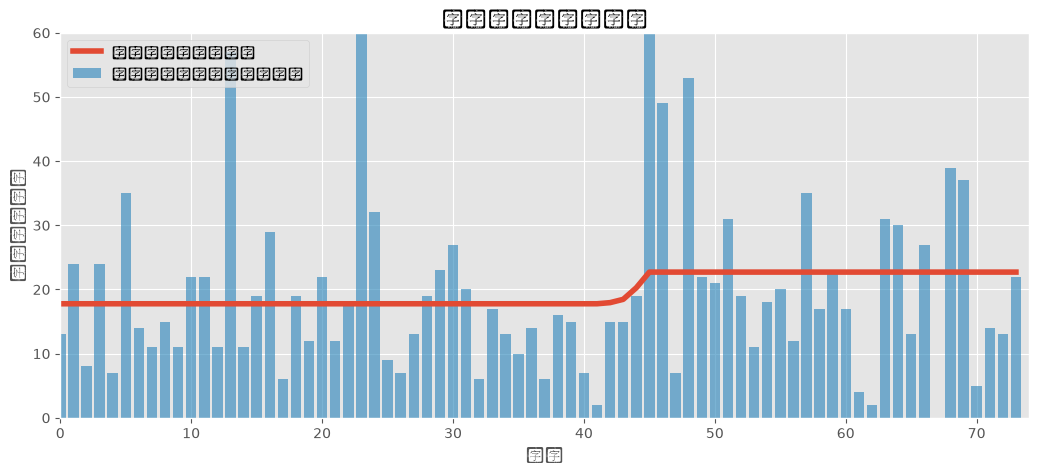

In [14]:

figsize(12.5, 5)
# tau_samples, lambda_1_samples, lambda_2_samples 里
# 保存着来自各自后验分布的 N 个样本
N = tau_samples.shape[0]
expected_texts_per_day = np.zeros(n_count_data)
for day in range(0, n_count_data):
    # ix 是一个布尔索引, 标出所有"切换点发生在 day 之前"的 tau 样本
    ix = day < tau_samples
    # 每一个后验样本都对应一个 tau 取值。
    # 对每一天来说, 这个 tau 值决定了我们是处于切换点"之前"
    # (也就是 lambda1 的"机制"下), 还是"之后"
    # (也就是 lambda2 的"机制"下)。
    # 据此取出对应的 lambda1/2 后验样本, 再对所有样本取平均,
    # 就能得到这一天 lambda 的期望值。
    # 如前所述, "短信条数"这个随机变量服从泊松分布,
    # 因此 lambda (泊松参数) 就是"短信条数"的期望值。
    expected_texts_per_day[day] = (lambda_1_samples[ix].sum()
                                    + lambda_2_samples[~ix].sum()) / N


plt.plot(range(n_count_data), expected_texts_per_day, lw=4, color="#E24A33",
         label="预期收到的短信条数")
plt.xlim(0, n_count_data)
plt.xlabel("天数")
plt.ylabel("预期短信条数")
plt.title("预期收到的短信条数")
plt.ylim(0, 60)
plt.bar(np.arange(len(count_data)), count_data, color="#348ABD", alpha=0.65,
        label="实际观测到的每日短信条数")

plt.legend(loc="upper left");



我们的分析有力地支持了"用户的行为确实发生了变化"这一判断(否则 $\lambda_1$ 和 $\lambda_2$ 的取值应该相近),并且这个变化是突然发生的,而不是逐渐发生的(体现在 $\tau$ 的后验分布有一个非常尖锐的峰值)。我们可以猜测这背后可能的原因:更便宜的短信资费、最近订阅了一个天气短信提醒服务,又或者是开始了一段新恋情。(事实上,第 45 天正好对应圣诞节,而我在下个月搬去了多伦多,留下了一位女朋友在原地。)



##### 习题

1. 用 `lambda_1_samples` 和 `lambda_2_samples`,算出 $\lambda_1$ 和 $\lambda_2$ 后验分布的均值分别是多少?


In [15]:

# 在这里写你的代码。



2. 短信频率的预期增幅百分比是多少?`提示:` 计算 `lambda_1_samples/lambda_2_samples` 的均值。注意这个量和 `lambda_1_samples.mean()/lambda_2_samples.mean()` 是很不一样的。


In [16]:

# 在这里写你的代码。



3. **已知** $\tau$ 小于 45 的条件下,$\lambda_1$ 的均值是多少?也就是说,假设我们得到了新信息:行为变化发生在第 45 天之前。那么现在 $\lambda_1$ 的期望值是多少?(不需要重新跑一遍 PyMC 部分,只需要考虑所有满足 `tau_samples < 45` 的样本即可。)


In [17]:

# 在这里写你的代码。



### 参考文献

- [1] Gelman, Andrew. N.p.. Web. 22 Jan 2013. [N is never large enough](http://andrewgelman.com/2005/07/31/n_is_never_larg)。
- [2] Norvig, Peter. 2009. [The Unreasonable Effectiveness of Data](http://static.googleusercontent.com/media/research.google.com/en//pubs/archive/35179.pdf)。
- [3] Salvatier, J, Wiecki TV, and Fonnesbeck C. (2016) Probabilistic programming in Python using PyMC3. *PeerJ Computer Science* 2:e55 <https://doi.org/10.7717/peerj-cs.55>
- [4] Jimmy Lin and Alek Kolcz. Large-Scale Machine Learning at Twitter. Proceedings of the 2012 ACM SIGMOD International Conference on Management of Data (SIGMOD 2012), pages 793-804, May 2012, Scottsdale, Arizona.
- [5] Cronin, Beau. "Why Probabilistic Programming Matters." 24 Mar 2013. Google, Online Posting to Google. Web. 24 Mar. 2013.
